FileUpload(value={}, accept='.png,.jpg,.jpeg', description='Upload')

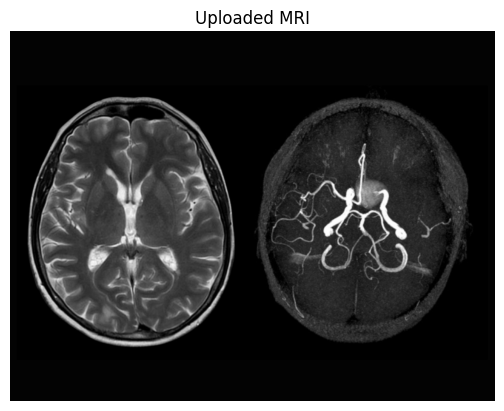

TypeError: 'jaxlib.xla_extension.ArrayImpl' object is not callable

In [14]:

# -*- coding: utf-8 -*-
"""
Brain Aneurysm Detection & SHAP Explanation (FLAX + SHAP)
"""

import jax
import jax.numpy as jnp
import flax.linen as nn
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import shap
import ipywidgets as widgets
from IPython.display import display
import io

# ------------------------------
# STEP 1: Define a simple CNN model using FLAX
# ------------------------------
class SimpleCNN(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Conv(features=8, kernel_size=(3, 3), padding='SAME')(x)
        x = nn.relu(x)
        x = nn.avg_pool(x, window_shape=(2, 2), strides=(2, 2))

        x = nn.Conv(features=16, kernel_size=(3, 3), padding='SAME')(x)
        x = nn.relu(x)
        x = nn.avg_pool(x, window_shape=(2, 2), strides=(2, 2))

        x = x.reshape((x.shape[0], -1))  # flatten
        x = nn.Dense(features=2)(x)
        return x

# ------------------------------
# STEP 2: Image upload widget
# ------------------------------
uploader = widgets.FileUpload(accept='.png,.jpg,.jpeg', multiple=False)
display(uploader)

def preprocess_image(img):
    img = img.convert("L").resize((128, 128))
    arr = np.array(img) / 255.0
    arr = arr.astype(np.float32)
    arr = arr.reshape(1, 128, 128, 1)
    return arr

def on_upload_change(change):
    if uploader.value:
        content = next(iter(uploader.value.values()))
        image = Image.open(io.BytesIO(content['content']))
        plt.imshow(image, cmap='gray')
        plt.title("Uploaded MRI")
        plt.axis('off')
        plt.show()

        input_image = preprocess_image(image)

        # ------------------------------
        # STEP 3: Initialize model
        # ------------------------------
        model = SimpleCNN()
        rng = jax.random.PRNGKey(0)
        variables = model.init(rng, jnp.array(input_image))

        def predict_fn(img):
            logits = model.apply(variables, img)
            return jax.nn.softmax(logits)

        # ------------------------------
        # STEP 4: Use SHAP
        # ------------------------------
        explainer = shap.Explainer(predict_fn, jnp.array(input_image))
        shap_values = explainer(jnp.array(input_image))

        # ------------------------------
        # STEP 5: Plot SHAP values
        # ------------------------------
        shap.image_plot(shap_values.values, shap_values.data)

uploader.observe(on_upload_change, names='value')
